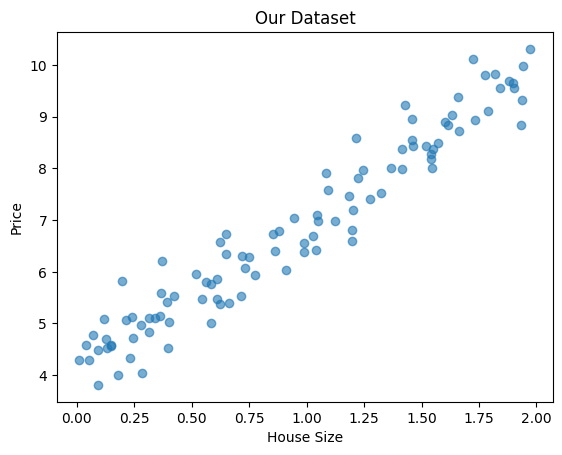

In [61]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X = 2 * np.random.rand(100)        # house sizes between 0-2 (scaled)
y = 4 + 3 * X + np.random.randn(100) * 0.5   # true line is y = 4 + 3x, with noise

plt.scatter(X, y, alpha=0.6)
plt.xlabel("House Size")
plt.ylabel("Price")
plt.title("Our Dataset")
plt.show()

Current loss: 0.5987
Current function equation: 3.9330x + 3.0118
Current loss: 0.2140
Current function equation: 3.0634x + 3.9055
Current loss: 0.2020
Current function equation: 2.9168x + 4.0716
Current loss: 0.2017
Current function equation: 2.8907x + 4.1012
Current loss: 0.2016
Current function equation: 2.8861x + 4.1064
Current loss: 0.2016
Current function equation: 2.8852x + 4.1073
Current loss: 0.2016
Current function equation: 2.8851x + 4.1075
Current loss: 0.2016
Current function equation: 2.8851x + 4.1075
Current loss: 0.2016
Current function equation: 2.8851x + 4.1075
Current loss: 0.2016
Current function equation: 2.8851x + 4.1075


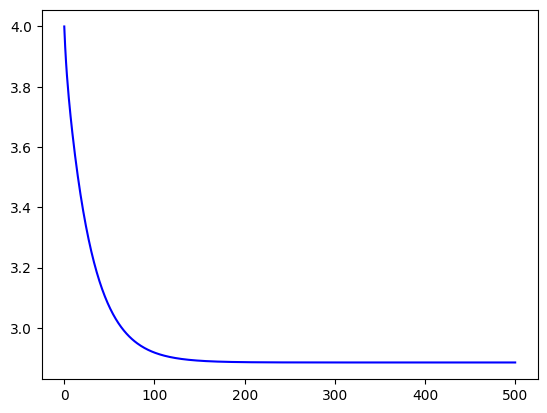

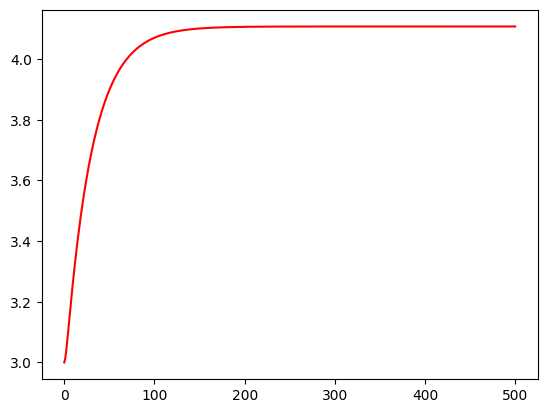

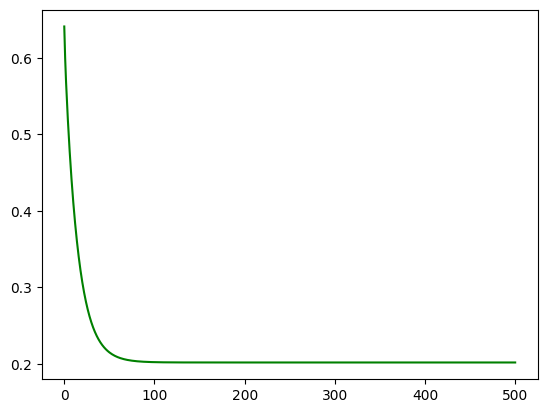

Line function after gradient descent: y=2.8851x + 4.1075
0.2016


In [62]:
def compute_mse(X, y, w, b):
  '''
  Function to compute mean squared error. Takes 2 arrays and 2 numbers as parameters.
  '''
  y_pred = w * X + b
  n = len(X)
  mse = (1 / n) * np.sum((y_pred - y) ** 2)

  return mse

w = 4 # Slope
b = 3 # Intercept
gamma = 0.1 # Learning rate


def compute_gradients(X, y, w, b):
    n = len(X)
    y_predicted = w * X + b          # make predictions with current w, b
    error = y_predicted - y          # how wrong are we for each point?

    dw = (2/n) * np.dot(X, error)   # slope of loss w.r.t. w (derivative)
    db = (2/n) * np.sum(error)      # slope of loss w.r.t. b (derivative)
    return dw, db                    # return both slopes

# Store these values to plot them over time
steps_w = [w]
steps_b = [b]
losses = [compute_mse(X, y, w, b)]

for epoch in range(500):
  dw, db = compute_gradients(X, y, w, b)
  w = w - gamma * dw
  b = b - gamma * db

  loss = compute_mse(X, y, w, b)
  losses.append(loss)
  steps_w.append(w)
  steps_b.append(b)

  if epoch % 50 == 0:
    print(f'Current loss: {loss:.4f}')
    print(f'Current function equation: {w:.4f}x + {b:.4f}')


plt.plot(range(501), steps_w, color='blue')
plt.show()
plt.plot(range(501), steps_b, color='red')
plt.show()
plt.plot(range(501), losses, color='green')
plt.show()


print(f"Line function after gradient descent: y={w:.4f}x + {b:.4f}")
print(f'{compute_mse(X, y, w, b):.4f}')

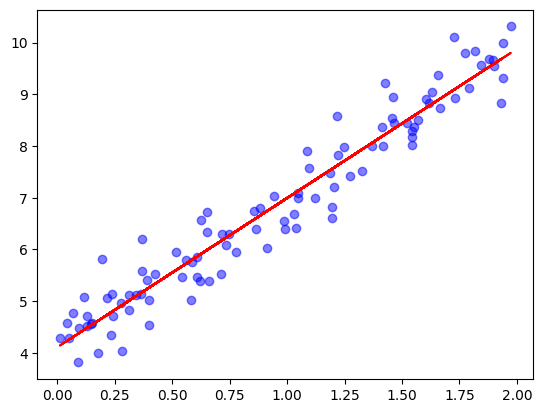

In [63]:
# Plot the results after performing gradient descent.
plt.scatter(X, y, color='blue', alpha=0.5)
plt.plot(X, w * X + b, color='red')
plt.show()